#  Entrenamiento y evaluación del modelo Random Forest para predicción
Este notebook forma parte del Anexo IV del Trabajo Fin de Máster.
En él se describe el proceso completo de carga de datos, preprocesado,
entrenamiento, validación y evaluación del modelo Random Forest.


In [1]:
!pip install xgboost


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
import skforecast
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_error
from skforecast.model_selection import TimeSeriesFold, grid_search_forecaster
from xgboost import XGBRegressor


np.random.seed(1234)




## Librerías y configuración del entorno

In [3]:

df_ambiente= pd.read_csv('prueba2.csv', sep=',', header=None)
df_week_40=pd.read_csv('s40.csv', sep=',', header=None)

df_ambiente.head()




,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,#group,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false
1,#datatype,double,double,double,double,double,double,double,double,long,long,double,long,double,double,double,double,dateTime:RFC3339
2,#default,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,bvoc,co2eq,gas,gas_resistencia,hum,humedad,iaq,lux,pm10_0,pm1_0,pm25_pred_1h,pm2_5,pres,presion,temp,temperatura,time
4,NaN,NaN,NaN,27.7,NaN,81.4,NaN,NaN,1.67,4,2,NaN,3,1018.05,NaN,16.75,NaN,2025-10-06T00:01:49.804443847Z


In [4]:
df_ambiente.shape

(8585, 18)

In [5]:
df_ambiente.isna().sum()

0     8582
1     8582
2     8582
3      881
4     8582
5      881
6     8582
7     8582
8      881
9      881
10     881
11    7702
12     881
13     881
14    8582
15     881
16    8582
17       1
dtype: int64

In [6]:

df_ambiente = df_ambiente.drop(df_ambiente.columns[[0,1,2,4,6,7,11,14,16]], axis=1)


df_ambiente = df_ambiente.drop(df_ambiente.index[[0,1,2]], axis=0)


df_ambiente

,3,5,8,9,10,12,13,15,17
3,gas,hum,lux,pm10_0,pm1_0,pm2_5,pres,temp,time
4,27.7,81.4,1.67,4,2,3,1018.05,16.75,2025-10-06T00:01:49.804443847Z
5,26.85,81.16,0.83,5,3,4,1018.16,16.61,2025-10-06T00:07:22.185193661Z
6,27.34,79.99,1.67,5,3,4,1018.21,16.49,2025-10-06T00:12:55.194415384Z
7,31.19,74.74,1.67,5,3,4,1018.27,16.43,2025-10-06T00:18:28.510440004Z
...,...,...,...,...,...,...,...,...,...
8580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:25:00Z
8581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:30:00Z
8582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:35:00Z
8583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:40:00Z


In [7]:
nombres_columnas = ['gas','humedad','lux','pm10','pm1','pm2.5','presion','temp','Fecha/hora']
df_ambiente.columns = nombres_columnas

df_ambiente = df_ambiente.drop(df_ambiente.index[[0]], axis=0)
df_ambiente

,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp,Fecha/hora
4,27.7,81.4,1.67,4,2,3,1018.05,16.75,2025-10-06T00:01:49.804443847Z
5,26.85,81.16,0.83,5,3,4,1018.16,16.61,2025-10-06T00:07:22.185193661Z
6,27.34,79.99,1.67,5,3,4,1018.21,16.49,2025-10-06T00:12:55.194415384Z
7,31.19,74.74,1.67,5,3,4,1018.27,16.43,2025-10-06T00:18:28.510440004Z
8,41.54,69.17,1.67,4,2,3,1018.32,16.43,2025-10-06T00:24:01.520771861Z
...,...,...,...,...,...,...,...,...,...
8580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:25:00Z
8581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:30:00Z
8582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:35:00Z
8583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:40:00Z


In [8]:
df_week_40 = df_week_40.drop(df_week_40.columns[[0,1,2,4,6,7,13,15]], axis=1)
df_week_40 = df_week_40.drop(df_week_40.index[[0,1,2]], axis=0)

In [9]:
 
nombres_columnas = ['gas','humedad','lux','pm10','pm1','pm2.5','presion','temp','Fecha/hora']
df_week_40.columns = nombres_columnas

df_week_40 = df_week_40.drop(df_ambiente.index[[0]], axis=0)
df_week_40

,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp,Fecha/hora
3,gas,hum,lux,pm10_0,pm1_0,pm2_5,pres,temp,time
5,19.84,75.3,0.83,17,12,16,1014.07,19.62,2025-09-30T00:07:10.215775097Z
6,19.79,74.47,0.83,17,11,15,1014.05,19.62,2025-09-30T00:12:47.292697787Z
7,19.94,74.01,0.83,16,12,15,1014.03,19.61,2025-09-30T00:18:19.300693929Z
8,20.35,73.77,0.83,16,12,15,1014,19.6,2025-09-30T00:23:51.395464121Z
...,...,...,...,...,...,...,...,...,...
1803,30.8,72.47,0.83,14,10,13,1016.12,21.29,2025-10-02T23:33:50.851340875Z
1804,30.03,72.77,0.83,12,9,12,1016.16,21.19,2025-10-02T23:39:23.771511753Z
1805,28.51,74.13,0.83,14,9,12,1016.2,21.02,2025-10-02T23:44:56.40615835Z
1806,26.53,73.81,0.83,14,10,13,1016.26,20.85,2025-10-02T23:50:28.642935837Z


In [10]:
print(df_week_40.columns)
print(df_ambiente.columns)


df_week_40.columns = df_ambiente.columns  


df_completo = pd.concat([df_week_40, df_ambiente], axis=0, ignore_index=True)



Index(['gas', 'humedad', 'lux', 'pm10', 'pm1', 'pm2.5', 'presion', 'temp',
       'Fecha/hora'],
      dtype='object')
Index(['gas', 'humedad', 'lux', 'pm10', 'pm1', 'pm2.5', 'presion', 'temp',
       'Fecha/hora'],
      dtype='object')


In [11]:

df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'], errors='coerce')
df_completo['Fecha/hora'] = df_completo['Fecha/hora'].dt.tz_localize(None)          # quita zona horaria
df_completo['Fecha/hora'] = df_completo['Fecha/hora'].dt.floor('s')   
df_completo = df_completo.sort_values(by='Fecha/hora', ascending=True)

print(df_completo.head())

       gas humedad   lux pm10 pm1 pm2.5  presion   temp          Fecha/hora
771  17.92   76.81  0.83   30  18    27  1012.43   20.8 2025-09-28 22:00:44
772  17.86   77.07  0.83   33  18    28  1012.44  20.75 2025-09-28 22:06:16
773  17.85   77.17  0.83   31  18    27  1012.47  20.69 2025-09-28 22:11:49
774  17.71   77.09  0.83   31  19    27   1012.5  20.66 2025-09-28 22:17:22
775  17.74   76.98  0.83   32  18    27  1012.53  20.65 2025-09-28 22:22:54


C:\Users\aleoj\AppData\Local\Temp\ipykernel_3588\1987491390.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'], errors='coerce')


In [12]:
df_completo.dtypes


gas                   object
humedad               object
lux                   object
pm10                  object
pm1                   object
pm2.5                 object
presion               object
temp                  object
Fecha/hora    datetime64[ns]
dtype: object

In [13]:

df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'])


inicio_datos = pd.to_datetime('2025-09-29 00:00:00')  
final_datos = pd.to_datetime('2025-10-26 23:59:59')   


df_completo = df_completo[
    (df_completo['Fecha/hora'] >= inicio_datos) &
    (df_completo['Fecha/hora'] <= final_datos)
]


df_completo = df_completo.sort_values(by='Fecha/hora')


print(df_completo.head())

       gas humedad   lux pm10 pm1 pm2.5  presion   temp          Fecha/hora
514   16.1   80.73  0.83   20  14    19  1012.23  19.81 2025-09-29 00:02:53
515  16.22   80.81  0.83   22  14    20  1012.23  19.77 2025-09-29 00:08:26
516  16.02   80.96  0.83   22  14    20  1012.25  19.73 2025-09-29 00:13:58
517   15.8   80.77  0.83   25  16    22  1012.28   19.7 2025-09-29 00:19:31
518   15.8   80.58  0.83   22  15    20   1012.3  19.69 2025-09-29 00:25:11


In [14]:
df_completo.dtypes

gas                   object
humedad               object
lux                   object
pm10                  object
pm1                   object
pm2.5                 object
presion               object
temp                  object
Fecha/hora    datetime64[ns]
dtype: object

In [15]:

df_completo = df_completo.sort_values("Fecha/hora")


gaps = df_completo["Fecha/hora"].diff()

gaps_min = gaps.dt.total_seconds() / 60

gaps_min.describe()


count    7474.000000
mean        5.394071
std         2.107234
min         0.000000
25%         5.533333
50%         5.550000
75%         5.550000
max        89.183333
Name: Fecha/hora, dtype: float64

In [16]:
df_completo.isna().sum()

gas           0
humedad       0
lux           0
pm10          0
pm1           0
pm2.5         0
presion       0
temp          0
Fecha/hora    0
dtype: int64

In [17]:

rows_with_nan = df_completo[df_completo.isna().any(axis=1)]


print(rows_with_nan[['Fecha/hora']])


Empty DataFrame
Columns: [Fecha/hora]
Index: []


In [18]:

nan_by_date = df_completo.groupby(df_completo['Fecha/hora'].dt.date).apply(lambda x: x.isna().sum())
print(nan_by_date)

            gas  humedad  lux  pm10  pm1  pm2.5  presion  temp  Fecha/hora
Fecha/hora                                                                
2025-09-29    0        0    0     0    0      0        0     0           0
2025-09-30    0        0    0     0    0      0        0     0           0
2025-10-01    0        0    0     0    0      0        0     0           0
2025-10-02    0        0    0     0    0      0        0     0           0
2025-10-03    0        0    0     0    0      0        0     0           0
2025-10-04    0        0    0     0    0      0        0     0           0
2025-10-05    0        0    0     0    0      0        0     0           0
2025-10-06    0        0    0     0    0      0        0     0           0
2025-10-07    0        0    0     0    0      0        0     0           0
2025-10-08    0        0    0     0    0      0        0     0           0
2025-10-09    0        0    0     0    0      0        0     0           0
2025-10-10    0        0 

In [19]:
fecha_hora=df_completo['Fecha/hora']

df_completo = df_completo.apply(pd.to_numeric, errors='coerce')

df_completo['Fecha/hora'] = fecha_hora



df_completo= df_completo.set_index('Fecha/hora')

df_completo = df_completo.sort_index()

df_completo.head()



,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp
Fecha/hora,,,,,,,,
2025-09-29 00:02:53,16.10,80.73,0.83,20,14,19,1012.23,19.81
2025-09-29 00:08:26,16.22,80.81,0.83,22,14,20,1012.23,19.77
2025-09-29 00:13:58,16.02,80.96,0.83,22,14,20,1012.25,19.73
2025-09-29 00:19:31,15.80,80.77,0.83,25,16,22,1012.28,19.70
2025-09-29 00:25:11,15.80,80.58,0.83,22,15,20,1012.30,19.69


In [20]:

df_completo = df_completo.resample("5min").mean()
df_completo = df_completo.interpolate(method="time", limit=3)
df_completo.isna().sum()


gas        36
humedad    36
lux        36
pm10       36
pm1        36
pm2.5      36
presion    36
temp       36
dtype: int64

In [21]:
df_completo=df_completo.dropna()
df_completo.isna().sum()


gas        0
humedad    0
lux        0
pm10       0
pm1        0
pm2.5      0
presion    0
temp       0
dtype: int64

In [22]:
df_completo

,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp
Fecha/hora,,,,,,,,
2025-09-29 00:00:00,16.10,80.730,0.83,20.0,14.0,19.0,1012.23,19.810
2025-09-29 00:05:00,16.22,80.810,0.83,22.0,14.0,20.0,1012.23,19.770
2025-09-29 00:10:00,16.02,80.960,0.83,22.0,14.0,20.0,1012.25,19.730
2025-09-29 00:15:00,15.80,80.770,0.83,25.0,16.0,22.0,1012.28,19.700
2025-09-29 00:20:00,15.80,80.675,0.83,23.5,15.5,21.0,1012.29,19.695
...,...,...,...,...,...,...,...,...
2025-10-26 23:35:00,118.88,71.840,0.83,3.0,2.0,3.0,1014.20,11.950
2025-10-26 23:40:00,143.41,69.920,0.83,3.0,2.0,2.0,1014.21,11.960
2025-10-26 23:45:00,163.57,69.400,0.83,2.0,1.0,2.0,1014.24,11.930


## División del conjunto de datos

2025-09-29 00:00:00 2025-10-19 23:00:00
2025-10-19 23:05:00 2025-10-26 23:55:00


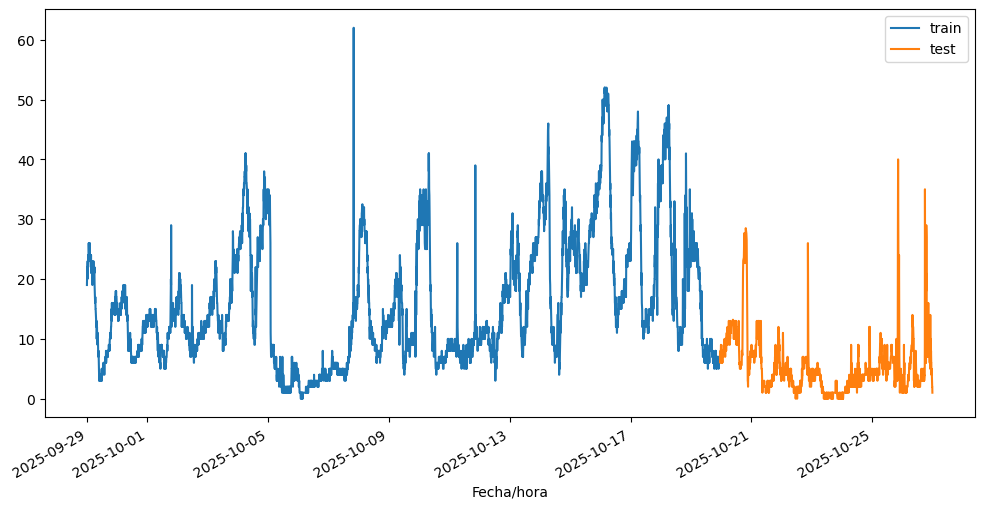

In [23]:
n = len(df_completo)
division = int(n * 0.75)

datos_train = df_completo.iloc[:division].copy()
datos_test  = df_completo.iloc[division:].copy()

print(datos_train.index.min(), datos_train.index.max())
print(datos_test.index.min(), datos_test.index.max())

fig, ax = plt.subplots(figsize=(12, 6))
datos_train['pm2.5'].plot(ax=ax, label='train')
datos_test['pm2.5'].plot(ax=ax, label='test')
ax.legend()


## Entrenamiento del modelo Random Forest

In [24]:
lags_pm25 = lags = [1, 3, 6, 12]


forecaster = ForecasterRecursive(
  regressor = RandomForestRegressor(random_state=123),
    lags = lags_pm25
)
forecaster.fit(y=datos_train['pm2.5'])
forecaster


C:\Users\aleoj\anaconda3\envs\pm25\lib\site-packages\skforecast\utils\utils.py:1157: UserWarning: Series has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
C:\Users\aleoj\anaconda3\envs\pm25\lib\site-packages\skforecast\utils\utils.py:1157: UserWarning: Series has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  3  6 12] 
Window features: None 
Window size: 12 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 6020] 
Training index type: RangeIndex 
Training index frequency: 1 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None,
    'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-01-31 10:55:21 
Last fit date: 2026-01-31 10:55:26 
Skforecast version: 0.14.0 
Python version: 3.10.19 
Forecaster id: None

In [25]:
pred_1h = forecaster.predict(steps=12)
pred_1h.head(3)



C:\Users\aleoj\anaconda3\envs\pm25\lib\site-packages\skforecast\utils\utils.py:1219: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


12    6.646962
13    6.723418
14    6.821858
Name: pred, dtype: float64

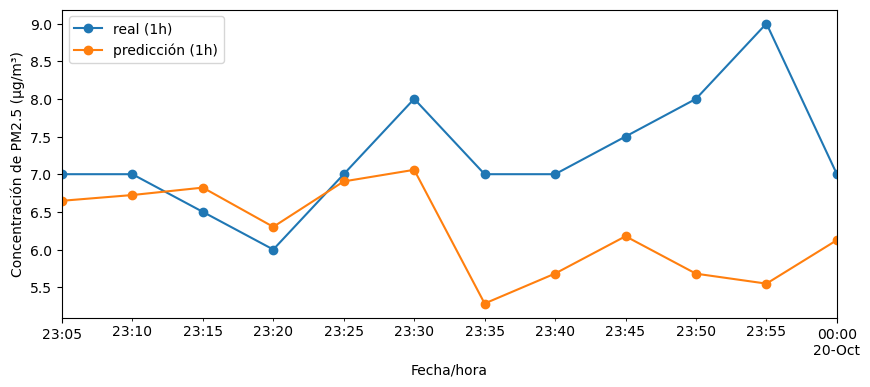

In [26]:
y_true_1h = datos_test['pm2.5'].iloc[:12]


pred_1h.index = y_true_1h.index

fig, ax = plt.subplots(figsize=(10, 4))

y_true_1h.plot(ax=ax, label='real (1h)', marker='o')
pred_1h.plot(ax=ax, label='predicción (1h)', marker='o')

ax.set_ylabel('Concentración de PM2.5 (µg/m³)')

ax.legend()
plt.show()



In [27]:
y_true = datos_test['pm2.5'].iloc[:12]

y_pred= pred_1h

MAE = mean_absolute_error(y_true,y_pred).round(2)

RMSE = mean_squared_error(y_true, y_pred).round(2)

print(f"Error de test (MAE): {MAE}")

print(f"Error de test (RMSE): {RMSE}")

Error de test (MAE): 1.11
Error de test (RMSE): 2.15


In [28]:
lags_pm25 = lags = [1, 3, 6, 12]


forecaster = ForecasterRecursive(
  regressor = RandomForestRegressor(random_state=123),
    lags = lags_pm25
)
forecaster.fit(y=datos_train['pm2.5'])
forecaster


C:\Users\aleoj\anaconda3\envs\pm25\lib\site-packages\skforecast\utils\utils.py:1157: UserWarning: Series has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(
C:\Users\aleoj\anaconda3\envs\pm25\lib\site-packages\skforecast\utils\utils.py:1157: UserWarning: Series has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  3  6 12] 
Window features: None 
Window size: 12 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 6020] 
Training index type: RangeIndex 
Training index frequency: 1 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None,
    'oob_score': False, 'random_state': 123, 'verbose': 0, 'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-01-31 10:55:27 
Last fit date: 2026-01-31 10:55:33 
Skforecast version: 0.14.0 
Python version: 3.10.19 
Forecaster id: None

In [29]:
pred_3h = forecaster.predict(steps=36)
pred_3h.head(3)


C:\Users\aleoj\anaconda3\envs\pm25\lib\site-packages\skforecast\utils\utils.py:1219: UserWarning: `last_window` has DatetimeIndex index but no frequency. Index is overwritten with a RangeIndex of step 1.
  warnings.warn(


12    6.646962
13    6.723418
14    6.821858
Name: pred, dtype: float64

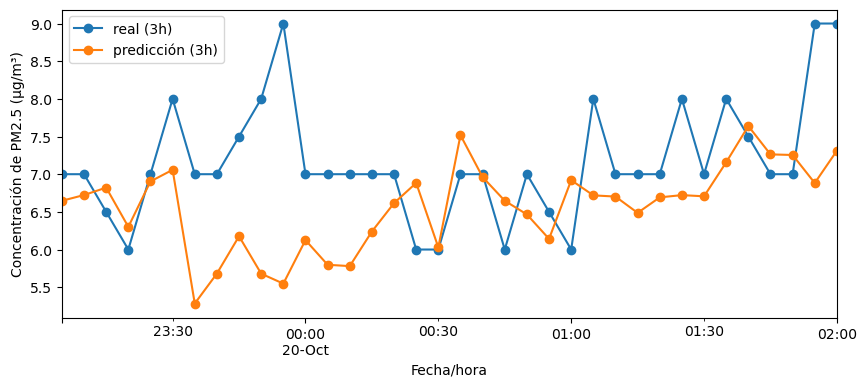

In [30]:
y_true_3h = datos_test['pm2.5'].iloc[:36]


pred_3h.index = y_true_3h.index

fig, ax = plt.subplots(figsize=(10, 4))

y_true_3h.plot(ax=ax, label='real (3h)', marker='o')
pred_3h.plot(ax=ax, label='predicción (3h)', marker='o')

ax.set_ylabel('Concentración de PM2.5 (µg/m³)')

ax.legend()
plt.show()



In [31]:
y_true = datos_test['pm2.5'].iloc[:36]

y_pred= pred_3h

MAE = mean_absolute_error(y_true,y_pred).round(2)

RMSE = mean_squared_error(y_true, y_pred).round(2)

print(f"Error de test (MAE): {MAE}")

print(f"Error de test (RMSE): {RMSE}")

Error de test (MAE): 0.84
Error de test (RMSE): 1.23


HIPERPARAMETROS

In [32]:
datos_train = datos_train.reset_index(drop=True)


forecaster = ForecasterRecursive(
    regressor = RandomForestRegressor(random_state=123),
    lags      = 12  
)

cv = TimeSeriesFold(
    steps              = 12,                           
    initial_train_size = int(len(datos_train) * 0.5), 
    refit              = False,
    fixed_train_size   = False
)


lags_grid = [6, 12, 24]  

param_grid = {
    'n_estimators': [100, 300],   
    'max_depth': [5, 10, None]   
}

resultados_grid = grid_search_forecaster(
    forecaster  = forecaster,
    y           = datos_train['pm2.5'],
    cv          = cv,
    param_grid  = param_grid,
    lags_grid   = lags_grid,
    metric      = 'mean_squared_error',  
    return_best = True,      
    n_jobs      = 'auto',
    verbose     = True
)

Number of models compared: 18.


lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

Information of folds
--------------------
Number of observations used for initial training: 3010
Number of observations used for backtesting: 3011
    Number of folds: 251
    Number skipped folds: 0 
    Number of steps per fold: 12
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 11 observations.

Fold: 0
    Training:   0 -- 3009  (n=3010)
    Validation: 3010 -- 3021  (n=12)
Fold: 1
    Training:   No training in this fold
    Validation: 3022 -- 3033  (n=12)
Fold: 2
    Training:   No training in this fold
    Validation: 3034 -- 3045  (n=12)
Fold: 3
    Training:   No training in this fold
    Validation: 3046 -- 3057  (n=12)
Fold: 4
    Training:   No training in this fold
    Validation: 3058 -- 3069  (n=12)
Fold: 5
    Training:   No training in this fold
    Validation: 3070 -- 3081  (n=12)
Fold: 6
    Training:   No training in this fold
    Validation: 3082 -- 3093  (n=12)
Fold: 7
    Training:   No

In [33]:
resultados_grid.head()
print(forecaster.lags)
print(forecaster.regressor)




[ 1  2  3  4  5  6  7  8  9 10 11 12]
RandomForestRegressor(max_depth=5, n_estimators=300, random_state=123)


In [34]:
lags_pm25 = [1,2,3,4,5,6,7,8,9,10,11,12]

forecaster = ForecasterRecursive(
  regressor = RandomForestRegressor(
      n_estimators=300,
      max_depth=None,
      random_state=123
  ),
    lags = lags_pm25
)
forecaster.fit(y=datos_train['pm2.5'])

In [35]:
pred_1h = forecaster.predict(steps=12)
pred_1h.head(3)

6021    6.626667
6022    6.365000
6023    6.357500
Name: pred, dtype: float64

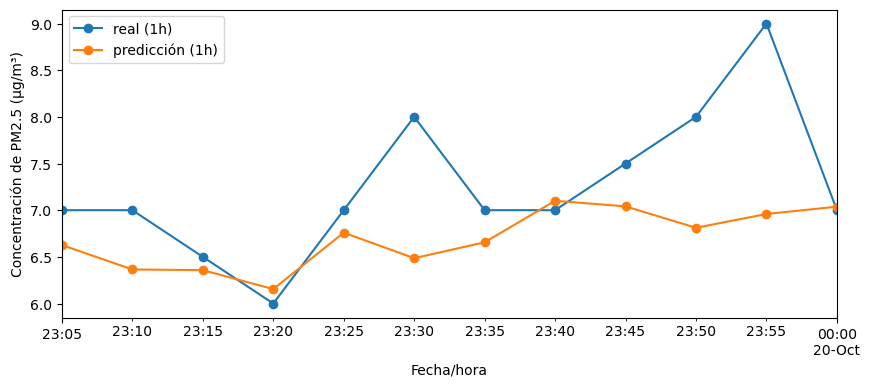

In [36]:
y_true_1h = datos_test['pm2.5'].iloc[:12]


pred_1h.index = y_true_1h.index

fig, ax = plt.subplots(figsize=(10, 4))

y_true_1h.plot(ax=ax, label='real (1h)', marker='o')
pred_1h.plot(ax=ax, label='predicción (1h)', marker='o')


ax.set_ylabel('Concentración de PM2.5 (µg/m³)')
ax.legend()
plt.show()


In [37]:
y_true = datos_test['pm2.5'].iloc[:12]

y_pred= pred_1h

MAE = mean_absolute_error(y_true,y_pred).round(2)

MSE = mean_squared_error(y_true, y_pred).round(2)

print(f"Error de test (MAE): {MAE}")

print(f"Error de test (RMSE): {MSE}")

Error de test (MAE): 0.6
Error de test (RMSE): 0.74


In [38]:
datos_train = datos_train.reset_index(drop=True)


forecaster = ForecasterRecursive(
    regressor = RandomForestRegressor(random_state=123),
    lags      = 12  
)

cv = TimeSeriesFold(
    steps              = 36,                           
    initial_train_size = int(len(datos_train) * 0.7), 
    refit              = False,
    fixed_train_size   = False
)


lags_grid = [12, 24, 36]   

param_grid = {
    'n_estimators': [100, 300],   
    'max_depth': [5, 10, None]    
}

resultados_grid = grid_search_forecaster(
    forecaster  = forecaster,
    y           = datos_train['pm2.5'],
    cv          = cv,
    param_grid  = param_grid,
    lags_grid   = lags_grid,
    metric      = 'mean_squared_error',  
    return_best = True,      
    n_jobs      = 'auto',
    verbose     = True
)

Number of models compared: 18.


lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

Information of folds
--------------------
Number of observations used for initial training: 4214
Number of observations used for backtesting: 1807
    Number of folds: 51
    Number skipped folds: 0 
    Number of steps per fold: 36
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 7 observations.

Fold: 0
    Training:   0 -- 4213  (n=4214)
    Validation: 4214 -- 4249  (n=36)
Fold: 1
    Training:   No training in this fold
    Validation: 4250 -- 4285  (n=36)
Fold: 2
    Training:   No training in this fold
    Validation: 4286 -- 4321  (n=36)
Fold: 3
    Training:   No training in this fold
    Validation: 4322 -- 4357  (n=36)
Fold: 4
    Training:   No training in this fold
    Validation: 4358 -- 4393  (n=36)
Fold: 5
    Training:   No training in this fold
    Validation: 4394 -- 4429  (n=36)
Fold: 6
    Training:   No training in this fold
    Validation: 4430 -- 4465  (n=36)
Fold: 7
    Training:   No t

In [39]:
resultados_grid.head()
print(forecaster.lags)
print(forecaster.regressor)


[ 1  2  3  4  5  6  7  8  9 10 11 12]
RandomForestRegressor(max_depth=10, random_state=123)


In [40]:
lags_pm25 = [1,2,3,4,5,6,7,8,9,10,11,12]

forecaster = ForecasterRecursive(
  regressor = RandomForestRegressor(
      n_estimators=100,
      max_depth=10,
      random_state=123
  ),
    lags = lags_pm25
)
forecaster.fit(y=datos_train['pm2.5'])

In [41]:
pred_3h = forecaster.predict(steps=36)
pred_3h.head(3)

6021    6.606149
6022    6.288144
6023    6.248174
Name: pred, dtype: float64

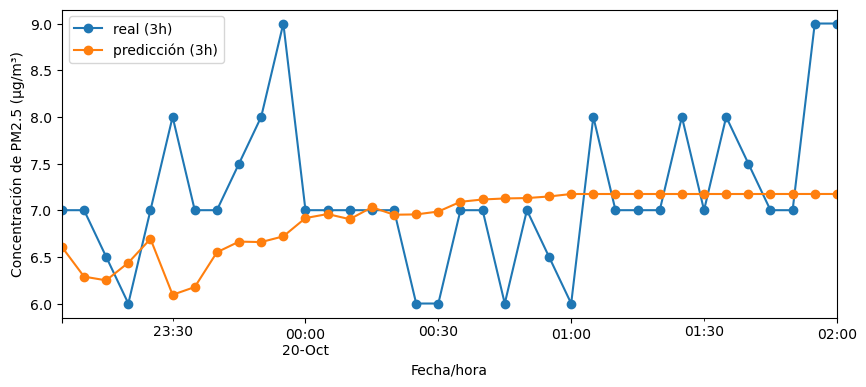

In [42]:
y_true_3h = datos_test['pm2.5'].iloc[:36]


pred_3h.index = y_true_3h.index

fig, ax = plt.subplots(figsize=(10, 4))

y_true_3h.plot(ax=ax, label='real (3h)', marker='o')
pred_3h.plot(ax=ax, label='predicción (3h)', marker='o')
ax.set_ylabel('Concentración de PM2.5 (µg/m³)')
ax.legend()
plt.show()


In [43]:
y_true = datos_test['pm2.5'].iloc[:36]

y_pred= pred_3h

MAE = mean_absolute_error(y_true,y_pred).round(2)

RMSE = mean_squared_error(y_true, y_pred).round(2)

print(f"Error de test (MAE): {MAE}")

print(f"Error de test (RMSE): {RMSE}")

Error de test (MAE): 0.63
Error de test (RMSE): 0.76


In [44]:
lags_pm25 = [1,2,3,4,5,6,7,8,9,10,11,12]

forecaster = ForecasterRecursive(
  regressor = RandomForestRegressor(
      n_estimators=300,
      max_depth=None,
      random_state=123
  ),
    lags = lags_pm25
)
forecaster.fit(y=datos_train['pm2.5'])



In [45]:
pred_3h = forecaster.predict(steps=36)
pred_3h.head(3)

6021    6.626667
6022    6.365000
6023    6.357500
Name: pred, dtype: float64

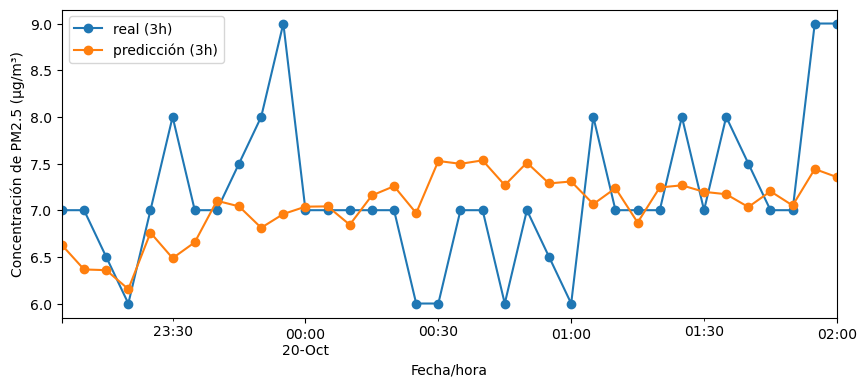

In [46]:
y_true_3h = datos_test['pm2.5'].iloc[:36]


pred_3h.index = y_true_3h.index

fig, ax = plt.subplots(figsize=(10, 4))

y_true_3h.plot(ax=ax, label='real (3h)', marker='o')
pred_3h.plot(ax=ax, label='predicción (3h)', marker='o')
ax.set_ylabel('Concentración de PM2.5 (µg/m³)')

ax.legend()
plt.show()
